# House Price Prediction

## Objective

Predict house prices using Machine Learning

Algorithm: 
- Multiple Linear Regression withoutbusing scikit learn

Libraries:
- Numpy
- Pandas
- Matplotlib
- seaborn 

Developer: 
Sahil Bhayre

# 1. Import Libraries

In [72]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

# 2. Load Dataset

In [73]:
data = pd.read_csv("Housing.csv")

# 3. Exploratory Data Analysis (EDA)

## 3.1 Display Dataset

In [74]:
data.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420.0,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960.0,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960.0,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500.0,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420.0,4,1,2,yes,yes,NaN,no,yes,2,no,unfurnished


In [75]:
data.tail()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
540,1820000,3000.0,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400.0,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620.0,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910.0,3,1,1,no,no,no,no,no,0,no,furnished
544,1750000,3850.0,3,1,2,yes,no,no,no,no,0,no,unfurnished


## 3.2 Dataset Info

In [76]:
data.shape

(545, 13)

In [77]:
data.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')

In [78]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   price             545 non-null    int64  
 1   area              544 non-null    float64
 2   bedrooms          545 non-null    int64  
 3   bathrooms         545 non-null    int64  
 4   stories           545 non-null    int64  
 5   mainroad          545 non-null    object 
 6   guestroom         545 non-null    object 
 7   basement          544 non-null    object 
 8   hotwaterheating   545 non-null    object 
 9   airconditioning   545 non-null    object 
 10  parking           545 non-null    int64  
 11  prefarea          545 non-null    object 
 12  furnishingstatus  545 non-null    object 
dtypes: float64(1), int64(5), object(7)
memory usage: 55.5+ KB


## 3.3 Check Missing

In [79]:
data.isnull().sum()

price               0
area                1
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            1
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [80]:
data[data.isnull().any(axis=1)]

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
4,11410000,7420.0,4,1,2,yes,yes,NaN,no,yes,2,no,unfurnished
24,8575000,NaN,3,2,2,yes,no,no,no,yes,2,no,furnished


## 3.4 Statistical Summary

In [81]:
data.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,544.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5143.832721,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2166.474646,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3596.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4580.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


## 3.5 Distribution Analysis

array([[<Axes: title={'center': 'price'}>,
        <Axes: title={'center': 'area'}>],
       [<Axes: title={'center': 'bedrooms'}>,
        <Axes: title={'center': 'bathrooms'}>],
       [<Axes: title={'center': 'stories'}>,
        <Axes: title={'center': 'parking'}>]], dtype=object)

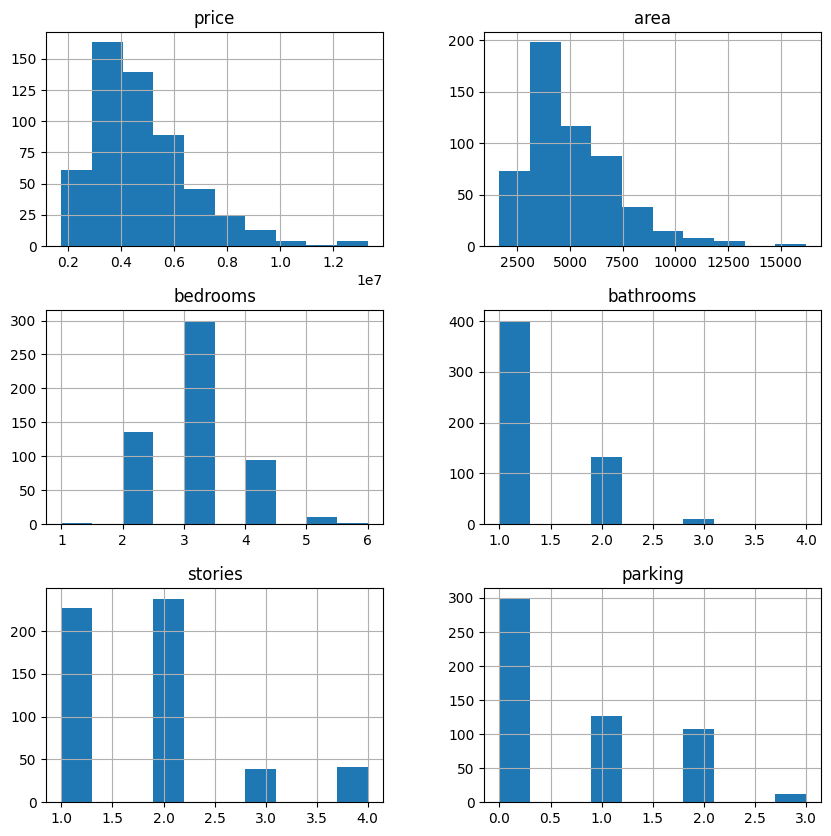

In [82]:
data.hist(figsize=(10, 10))

## 3.6 Correlation Analysis

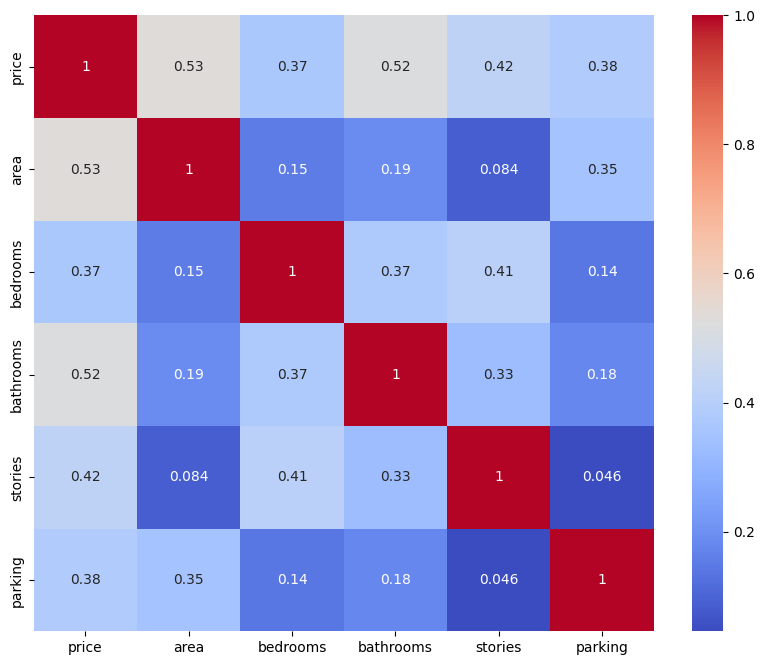

In [83]:
data.corr(numeric_only=True)
plt.figure(figsize=(10,8))
sns.heatmap(data.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.savefig("graphs/Correlation Analysis")
plt.show()

## 3.7 Target Variable Analysis

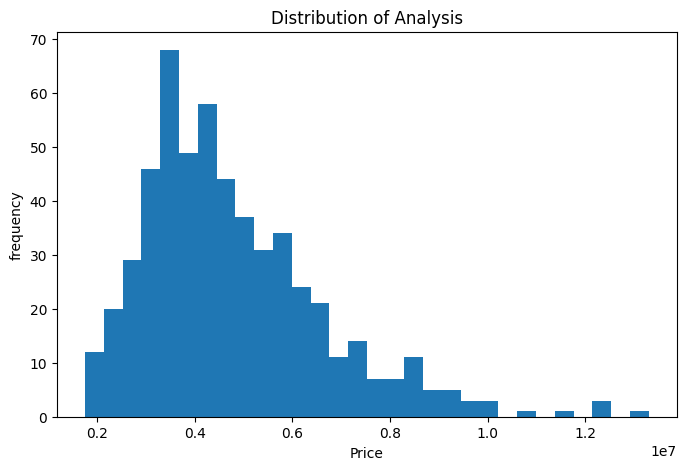

In [84]:
plt.figure(figsize=(8,5))
plt.hist(data['price'], bins=30)
plt.title("Distribution of Analysis")
plt.xlabel('Price')
plt.ylabel('frequency')
plt.savefig("graphs/ Distrubution of Analysis")
plt.show()

## 3.8 Categorical analysis

Index(['mainroad', 'guestroom', 'basement', 'hotwaterheating',
       'airconditioning', 'prefarea', 'furnishingstatus'],
      dtype='object')

mainroad
['yes' 'no']
mainroad
yes    468
no      77
Name: count, dtype: int64


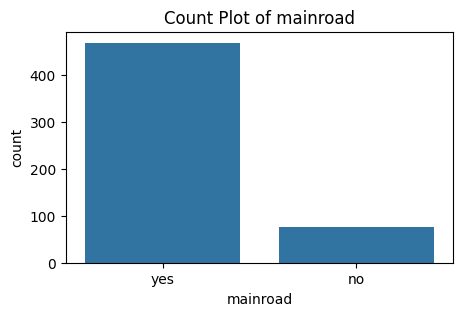


guestroom
['no' 'yes']
guestroom
no     448
yes     97
Name: count, dtype: int64


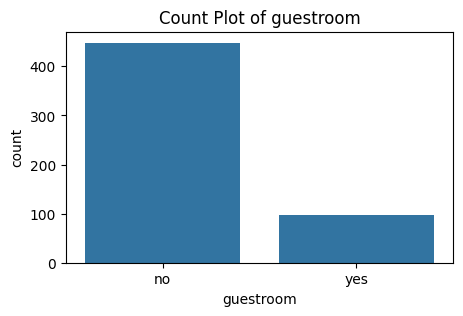


basement
['no' 'yes' nan]
basement
no     354
yes    190
Name: count, dtype: int64


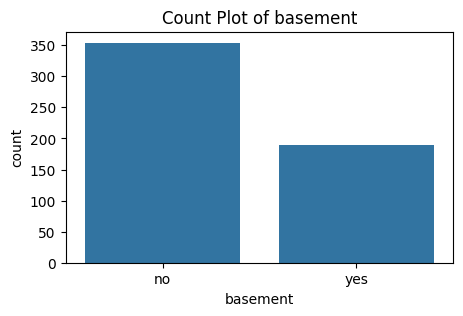


hotwaterheating
['no' 'yes']
hotwaterheating
no     520
yes     25
Name: count, dtype: int64


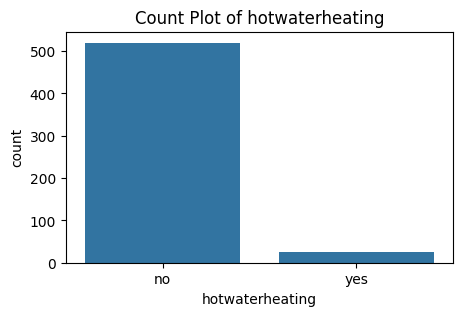


airconditioning
['yes' 'no']
airconditioning
no     373
yes    172
Name: count, dtype: int64


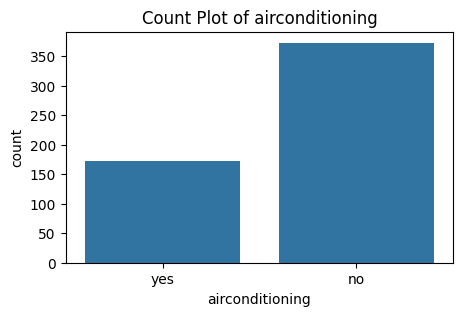


prefarea
['yes' 'no']
prefarea
no     417
yes    128
Name: count, dtype: int64


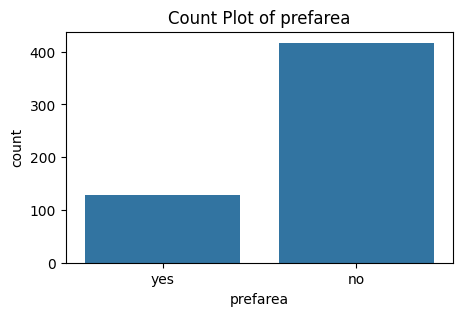


furnishingstatus
['furnished' 'semi-furnished' 'unfurnished']
furnishingstatus
semi-furnished    227
unfurnished       179
furnished         139
Name: count, dtype: int64


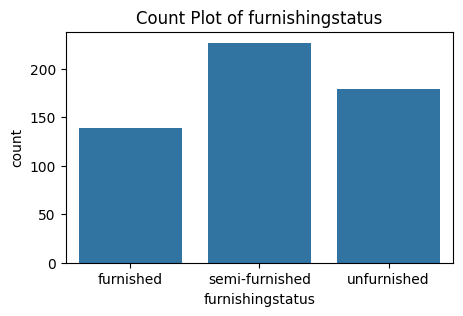

In [85]:
categorical_columns = data.select_dtypes(include=['object']).columns
print(categorical_columns)

for col in categorical_columns:
    print(f"\n{col}")
    print(data[col].unique())
    print(data[col].value_counts())
    plt.figure(figsize=(5,3))
    sns.countplot(x=col, data=data)
    plt.title(f"Count Plot of {col}")
    plt.show()

## 3.9 Scatter Plot

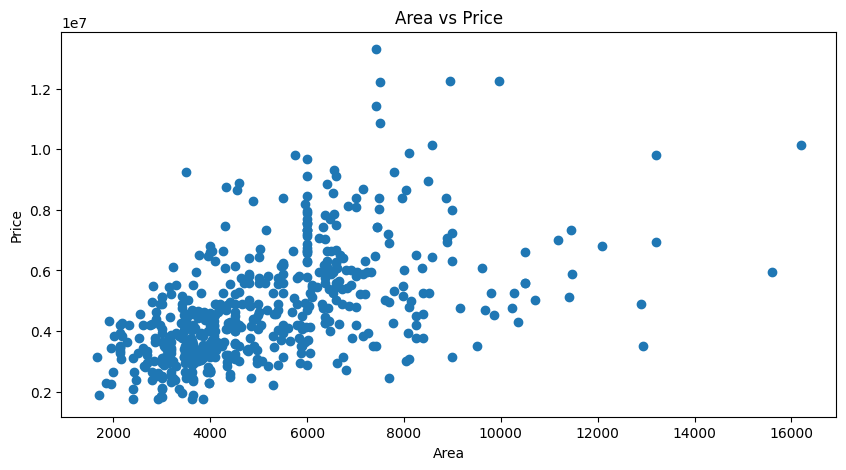

In [86]:
plt.figure(figsize=(10, 5))

plt.scatter(data['area'], data['price'])
plt.xlabel("Area")
plt.ylabel("Price")

plt.title("Area vs Price")
plt.savefig("graphs/Area vs Price")
plt.show()

## 3.10 Outlier Detection

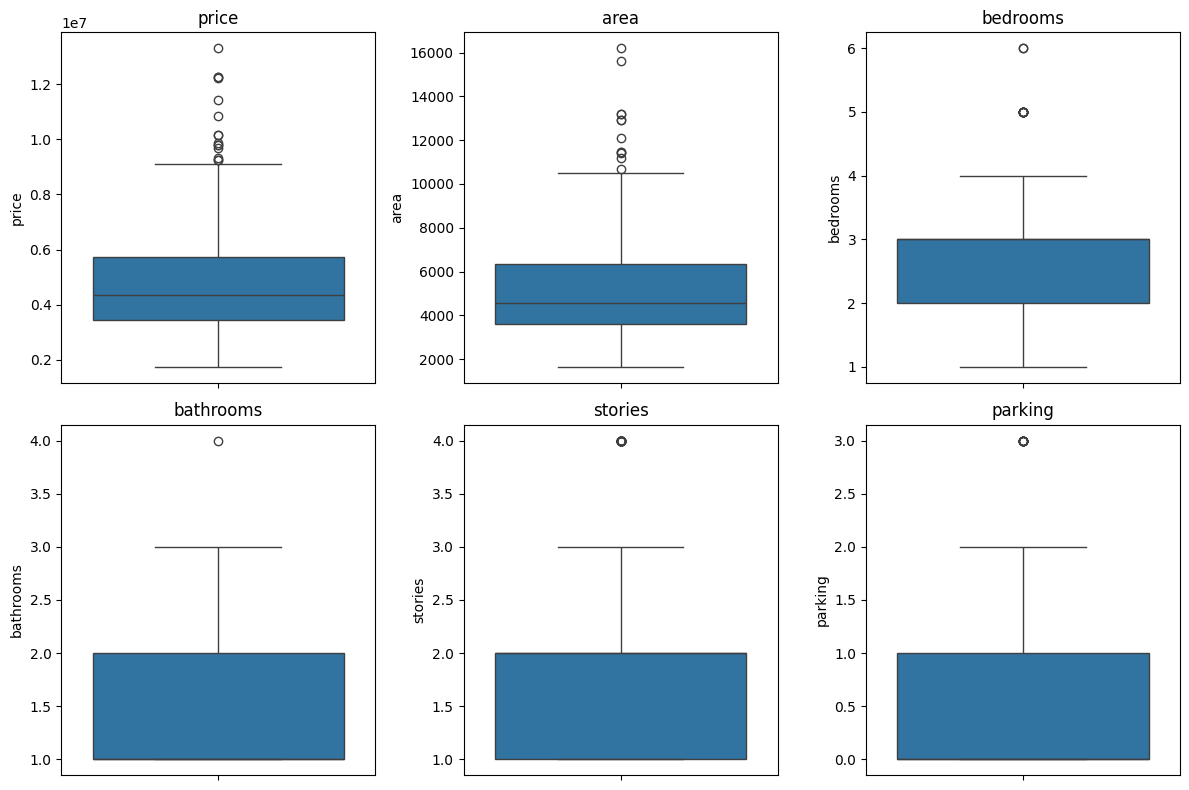

In [87]:
plt.figure(figsize=(12,8))
numerical_columns = [
    "price",
    "area",
    "bedrooms",
    "bathrooms",
    "stories",
    "parking"
]
for i, col in enumerate(numerical_columns, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=data[col])
    plt.title(col)

plt.tight_layout()
plt.savefig("graphs/Outlier Detection")
plt.show()

## 4. Data Preprocessing

## 4.1 Handle Missing Value

In [88]:
data['area'] = data['area'].fillna(data['area'].median())

In [89]:
data['basement'] = data['basement'].fillna(data['basement'].mode()[0])

## 4.2 Handle Categorical Feature

In [90]:
data.select_dtypes(include='object')

,mainroad,guestroom,basement,hotwaterheating,airconditioning,prefarea,furnishingstatus
0,yes,no,no,no,yes,yes,furnished
1,yes,no,no,no,yes,no,furnished
2,yes,no,yes,no,no,yes,semi-furnished
3,yes,no,yes,no,yes,yes,furnished
4,yes,yes,no,no,yes,no,unfurnished
...,...,...,...,...,...,...,...
540,yes,no,yes,no,no,no,unfurnished
541,no,no,no,no,no,no,semi-furnished
542,yes,no,no,no,no,no,unfurnished
543,no,no,no,no,no,no,furnished


In [91]:
binary_cols = [
    'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea'
]

for col in binary_cols:
    data[col] = data[col].map({'yes': 1, 'no': 0})

In [92]:
data = pd.get_dummies(
    data, 
    columns=['furnishingstatus'],
    drop_first = True, 
    dtype = int
)
dummy_cols = [
    "furnishingstatus_semi-furnished",
    "furnishingstatus_unfurnished"
]

data[dummy_cols] = data[dummy_cols].astype(int)

In [93]:
data.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420.0,4,2,3,1,0,0,0,1,2,1,0,0
1,12250000,8960.0,4,4,4,1,0,0,0,1,3,0,0,0
2,12250000,9960.0,3,2,2,1,0,1,0,0,2,1,1,0
3,12215000,7500.0,4,2,2,1,0,1,0,1,3,1,0,0
4,11410000,7420.0,4,1,2,1,1,0,0,1,2,0,0,1


# 5. Feature Selection

In [94]:
x = data.drop('price', axis=1)
y = data['price']
print(x.shape)
print(y.shape)

(545, 13)
(545,)


# 6. Train - Test Split

## 6.1 Shuffle

In [95]:
indices = np.arange(len(x))
np.random.shuffle(indices)

x = x.iloc[indices].reset_index(drop=True)
y = y.iloc[indices].reset_index(drop=True)

## 6.2 Calculate Train size

In [96]:
train_size = int(0.8 * len(x))
print(train_size)

436


## 6.3 Split Data

In [97]:
x_train = x[:train_size]
x_test = x[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

## 6.4 Verify

In [98]:
print("X_train:", x_train.shape)
print("X_test :", x_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (436, 13)
X_test : (109, 13)
y_train: (436,)
y_test : (109,)


# 7. Feature Scaling

In [99]:
mean = x_train.mean(axis=0)
std = x_train.std(axis=0)

In [100]:
x_train = (x_train - mean) / std
x_test = (x_test - mean) / std

# 8. Initialize Parameter

In [101]:
w = np.zeros(x_train.shape[1])
b = 0

In [102]:
print("Initial Weights:")
print(w)

print("\nShape of Weights:", w.shape)

print("\nInitial Bias:", b)

Initial Weights:
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]

Shape of Weights: (13,)

Initial Bias: 0


# 9. Prediction Function

In [103]:
def predict(x, w, b):
    y_pred = np.dot(x, w) + b

    return y_pred

In [104]:
predictions = predict(x_train, w, b)

print(predictions[:5])

[0. 0. 0. 0. 0.]


# 10. Cost Function

In [105]:
def compute_cost(x, y, w, b):
    m = len(y)
    prediction = np.dot(x, w) + b
    error = prediction - y
    cost = np.sum(error ** 2) / (2 * m)
    return cost

In [106]:
cost = compute_cost(x_train, y_train, w, b)

print("Initial Cost:", cost)

Initial Cost: 12922616009149.771


# 11. Gradient Function

In [107]:
def compute_gradient(x, y, w, b):
    m = len(x)
    prediction = np.dot(x, w) + b
    error = prediction - y
    dj_dw = np.dot(x.T, error) / m
    dj_db = np.sum(error) / m
    
    return dj_dw, dj_db

In [108]:
dj_dw, dj_db = compute_gradient(x_train, y_train , w, b)
print("Initial dj_dw::", dj_dw)
print("Initial dj_db:", dj_db)

Initial dj_dw:: [-970745.86522546 -662485.70106377 -940218.649356   -795519.51106736
 -535025.19792503 -451167.09070059 -363026.21751836 -135741.62518486
 -847607.04725596 -684408.80279157 -614571.40131385  -75609.19626581
  487777.01098336]
Initial dj_db: -4744136.330275229


# 12. Gradient Descent

In [109]:
def gradient_descent(X, y, w, b, alpha, iterations):
    cost_history = []
    
    for i in range(iterations):
        dj_dw, dj_db = compute_gradient(X, y, w, b)
        
        w = w - alpha * dj_dw
        b = b - alpha * dj_db
        
        cost_history.append(compute_cost(X, y, w, b))
        
        if i % 1000 == 0:
            print(f"Iteration {i}, Cost: {cost_history[-1]:.2e}")
    
    return w, b, cost_history

# 13. Train Model

In [110]:
alpha = 0.01
iteration = 2000

w_final, b_final, cost_history = gradient_descent(
    x_train,
    y_train,
    w,
    b,
    alpha, 
    iteration
)


print("\nFinal w:", w_final)
print("Final b:", b_final)


Iteration 0, Cost: 1.26e+13


Iteration 1000, Cost: 5.37e+11

Final w: [ 505232.24390106   71965.3018308   483498.13099907  394613.32288357
  142998.65086325   75543.30610854  195681.6902387   154750.18661778
  396695.94995482  228460.58846354  288355.67435237  -38921.73853114
 -179804.50010429]
Final b: 4744136.321433309


# 14. Prediction

## 14.1 Predict on test data

In [111]:
y_pred = predict(x_test, w_final, b_final)
print(f"Actual Price: {y_test.iloc[1]}")
print(f"Predicted Price: {y_pred[1]}")

Actual Price: 3150000
Predicted Price: 4149504.0050382814


## 14.2 Custom Prediction

### Input Feature

In [112]:
new_house = np.array([
    7420,  # area
    4,     # bedrooms
    2,     # bathrooms
    3,     # stories
    1,     # mainroad (Yes)
    0,     # guestroom (No)
    0,     # basement (No)
    0,     # hotwaterheating (No)
    1,     # airconditioning (Yes)
    2,     # parking
    1,     # prefarea (Yes)
    0,     # furnishingstatus_semi-furnished
    0      # furnishingstatus_unfurnished
])

### Scale and Reshape

In [113]:
new_house = (new_house - mean.values) / std.values
new_house = new_house.reshape(1, -1)

### Predict Price

In [114]:
predicted_price = predict(new_house, w_final, b_final)
print(f"\nPredicted House Price: ₹{predicted_price[0]:,.2f}")


Predicted House Price: ₹8,028,524.66


## 14.3 Prediction using User Input

### User Input

In [115]:
area = float(input("Enter Area: "))
bedrooms = int(input("Enter Bedrooms: "))
bathrooms = int(input("Enter Bathrooms: "))
stories = int(input("Enter Stories: "))
mainroad = int(input("Main Road (Yes=1, No=0): "))
guestroom = int(input("Guest Room (Yes=1, No=0): "))
basement = int(input("Basement (Yes=1, No=0): "))
hotwaterheating = int(input("Hot Water Heating (Yes=1, No=0): "))
airconditioning = int(input("Air Conditioning (Yes=1, No=0): "))
parking = int(input("Parking Spaces: "))
prefarea = int(input("Preferred Area (Yes=1, No=0): "))
furnishing = input(
    "Furnishing (furnished / semi-furnished / unfurnished): "
).lower()

### Encode Furnishing Status

In [116]:
if furnishing == "furnished":
    semi_furnished = 0
    unfurnished = 0

elif furnishing == "semi-furnished":
    semi_furnished = 1
    unfurnished = 0

elif furnishing == "unfurnished":
    semi_furnished = 0
    unfurnished = 1

else:
    print("Invalid furnishing status")

### Input Array

In [117]:
new_house = np.array([
    area,
    bedrooms,
    bathrooms,
    stories,
    mainroad,
    guestroom,
    basement,
    hotwaterheating,
    airconditioning,
    parking,
    prefarea,
    semi_furnished,
    unfurnished
])

### Scale

In [118]:
new_house = (new_house - mean.values) / std.values

### Reshape

In [119]:
new_houses = new_house.reshape(1, -1)

### Prediction

In [120]:
predicted_price = predict(new_houses, w_final, b_final)

print(f"\nPredicted House Price: ₹{predicted_price[0]:,.2f}")


Predicted House Price: ₹5,789,454.81


# 15. Model Evaluation

## 15.1 Mean Absolute Error

In [121]:
mae = np.mean(np.abs(y_test - y_pred))
print("Mean Absolute Error (MAE):", mae)

Mean Absolute Error (MAE): 804184.2317154531


## 15.2 Mean Squared Error

In [122]:
mse = np.mean((y_test - y_pred) ** 2)

print("Mean Squared Error (MSE):", mse)

Mean Squared Error (MSE): 1403407250712.506


## 15.3 Root Mean Squared Error

In [123]:
rmse = np.sqrt(mse)

print("Root Mean Squared Error (RMSE):", rmse)

Root Mean Squared Error (RMSE): 1184654.907858194


## 15.4 R2 Score

In [124]:
ss_total = np.sum((y_test - np.mean(y_test)) ** 2)

ss_residual = np.sum((y_test - y_pred) ** 2)

r2 = 1 - (ss_residual / ss_total)

print("R² Score:", r2)

R² Score: 0.6574387059986526


# 16. Visualizations

## 16.1 Cost vs Iterations

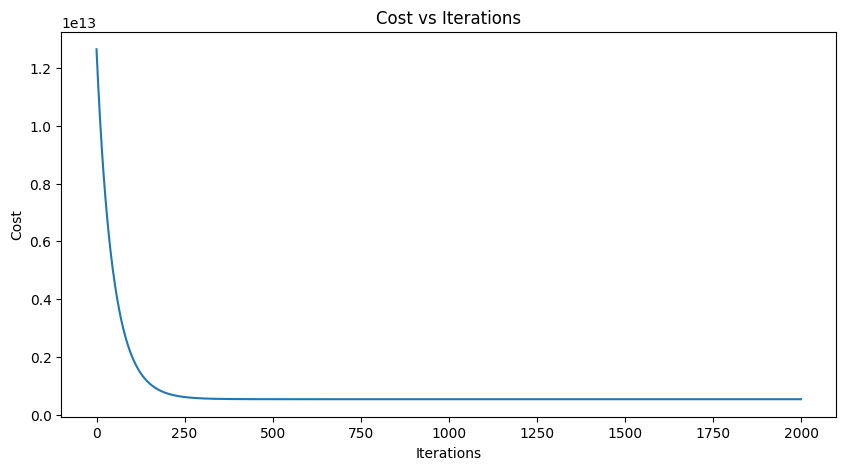

In [125]:
plt.figure(figsize=(10, 5))
plt.plot(cost_history)
plt.title("Cost vs Iterations")
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.savefig("graphs/Cost vs Iterations")
plt.show()

## 16.2 Actual vs Predicted Scatter Plot

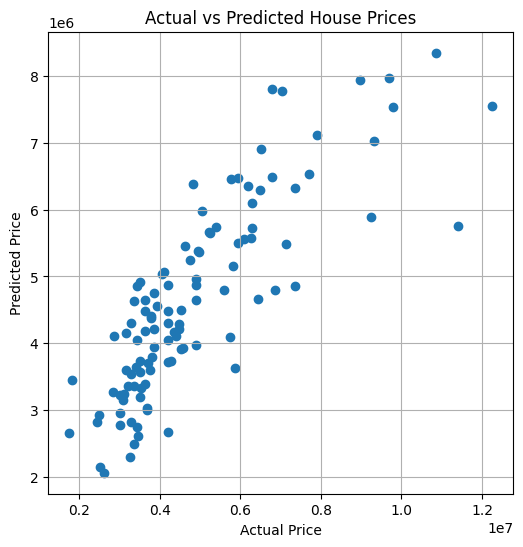

In [126]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, )

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")
plt.grid(True)
plt.savefig("graphs/Actual vs Predicted Price")
plt.show()

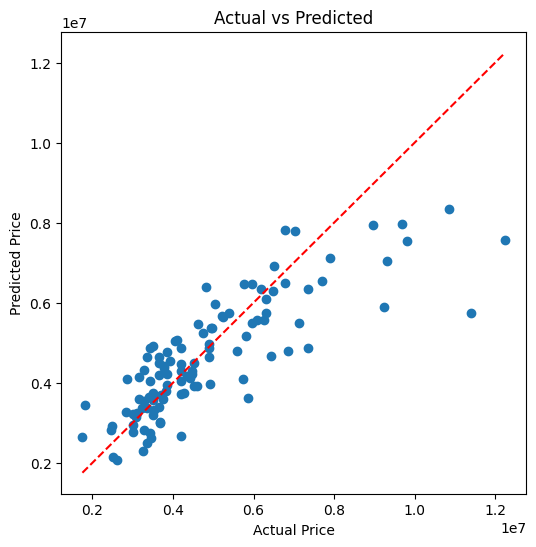

In [127]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red',
    linestyle='--'
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")
plt.savefig("graphs/Prediction Line")
plt.show()

## 16.3 Prediction Error Distribution

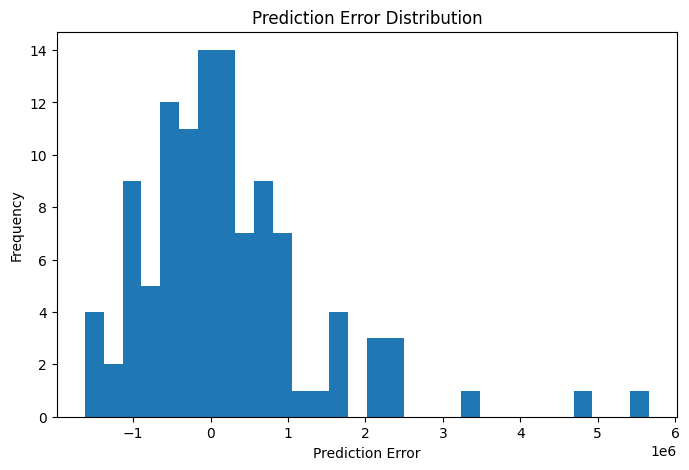

In [131]:
errors = y_test - y_pred

plt.figure(figsize=(8,5))
plt.hist(errors, bins=30)

plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.title("Prediction Error Distribution")
plt.savefig("graphs/Prediction Error vs frequency")
plt.show()

## 15.4 Residual Plot

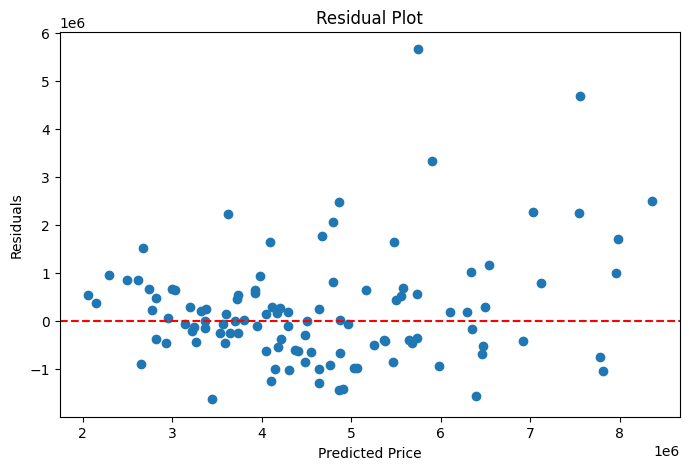

In [129]:
residuals = y_test - y_pred

plt.figure(figsize=(8,5))
plt.scatter(y_pred, residuals)

plt.axhline(0, color='red', linestyle='--')

plt.xlabel("Predicted Price")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.savefig("graphs/Predicted Price vs Residual")
plt.show()

# 😜 Project Summary

In this project, I developed a House Price Prediction System by implementing Multiple Linear Regression from scratch using NumPy, without using any machine learning libraries such as scikit-learn. The objective was to understand the complete mathematical foundation of Linear Regression and build the algorithm step by step.

The project began with Exploratory Data Analysis (EDA), where I analyzed the dataset, checked missing values, studied feature distributions, detected outliers, and examined the relationships between different features. I then performed data preprocessing, including handling categorical variables through one-hot encoding, splitting the dataset into training and testing sets, and applying feature scaling using standardization.

After preprocessing, I manually implemented the core components of Multiple Linear Regression:
- Prediction Function
- Cost Function
- Gradient Function
- Gradient Descent Optimization
- Model Training
- House Price Prediction

The model was evaluated using standard regression metrics:
- Mean Absolute Error (MAE): ₹779,710.27
- Mean Squared Error (MSE): 1.146 × 10¹²
- Root Mean Squared Error (RMSE): ₹1,070,742.18
- R² Score: 0.6609

The model explains approximately 66% of the variation in house prices, showing that multiple features significantly improve prediction accuracy compared to Simple Linear Regression.

To better understand the model's performance, I created several visualizations, including:
- Cost vs Iterations
- Actual vs Predicted House Prices
- Residual Plot
- Prediction Error Distribution

These visualizations confirmed that the Gradient Descent algorithm converged successfully and that the model provides reasonably accurate predictions for the housing dataset.

Overall, this project strengthened my understanding of Linear Regression, Gradient Descent, feature engineering, data preprocessing, and regression model evaluation. It also provided a strong foundation for learning machine learning libraries such as scikit-learn and more advanced regression techniques in future projects.